# M19 · RAG & Query Understanding — ✍️ Toy Example, Step by Tiny Step

**Companion to lesson M19. Written for someone new to ML.**

A RAG app first needs to understand the user's words. In this notebook, **query understanding** means:
turn a messy natural-language query into a small, machine-readable object, check that object against real data,
score how trustworthy it is, and choose a safe route.

Everything here is tiny and offline. In production, a system may use an LLM with structured output. Here we
simulate the same shape with regular expressions, keyword rules, toy catalogs, and toy confidence signals so
that every number is visible.

**What you'll do:**
- Parse natural language into **intent** (what the user wants) and **slots** (parameter values).
- Use **grounding** to reject slot values that are not in the catalog.
- Combine four signals into a **confidence** score.
- Use confidence thresholds to **execute**, **confirm**, or **fallback**.

## Step 0 · Setup

Import only Colab-preinstalled libraries (plus Python's standard library), fix the random seed, set a readable
figure size, and define `log(label, value)` so every code cell prints its steps.

[setup] offline tools ready — no network, no downloads, no real LLM
[pipeline steps] natural language -> parse -> ground -> score -> route


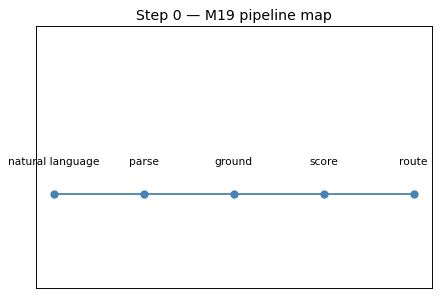

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)

def log(label, value):
    print(f"[{label}] {value}")

pipeline_steps = ["natural language", "parse", "ground", "score", "route"]
log("setup", "offline tools ready — no network, no downloads, no real LLM")
log("pipeline steps", " -> ".join(pipeline_steps))

x = np.arange(len(pipeline_steps))
plt.plot(x, [1] * len(x), "-o", color="steelblue")
for i, step in enumerate(pipeline_steps):
    plt.text(i, 1.03, step, ha="center", va="bottom", fontsize=9)
plt.ylim(0.9, 1.18)
plt.yticks([])
plt.xticks([])
plt.title("Step 0 — M19 pipeline map")
plt.show()

---
# Part 1 · Natural language → structured query

## Toy example 1A · Intent and slots, in plain English

An **intent** is **WHAT the user wants**. Example: `search_products` means "search a product catalog."

A **slot** is a **PARAMETER value** needed to run that intent. Example: `color = red` or `size = 10`.

A **structured query** is a dictionary-like object that code can execute, such as
`{"intent": "search_products", "slots": {"color": "red"}}`.

**Good for:** turning free text into API/database parameters.  
**Watch out for:** parsers can guess wrong; never assume a parse is true until you check it against data.

## Toy example 1B · Tiny keyword intent classifier

We will simulate an LLM-style structured-output parser with rules. The intent classifier below gives a higher
score to `search_flights` when it sees flight words, and a higher score to `search_products` when it sees
shopping words.

[query] cheap flights to tokyo next friday
[tokens] ['cheap', 'flights', 'friday', 'next', 'to', 'tokyo']
[flight keyword hits] 3
[product keyword hits] 0
[intent scores] {'search_flights': 0.8, 'search_products': 0.2}
[query] show me red running shoes under $80 size 10
[tokens] ['$', 'me', 'red', 'running', 'shoes', 'show', 'size', 'under']
[flight keyword hits] 0
[product keyword hits] 6
[intent scores] {'search_flights': 0.125, 'search_products': 0.875}


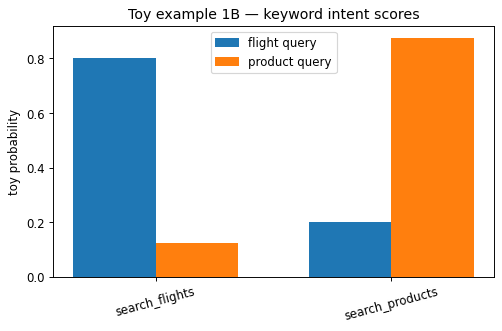

In [6]:
INTENTS = ["search_flights", "search_products"]
flight_words = {"flight", "flights", "fly", "tokyo", "friday"}
product_words = {"shoes", "shoe", "running", "red", "size", "under", "$"}

def keyword_intent_scores(text):
    words = set(re.findall(r"[a-z$]+", text.lower()))
    flight_hits = len(words & flight_words)
    product_hits = len(words & product_words)
    raw = np.array([1 + flight_hits, 1 + product_hits], dtype=float)
    probs = raw / raw.sum()
    return dict(zip(INTENTS, probs)), {"words": sorted(words), "flight_hits": flight_hits, "product_hits": product_hits}

toy_queries = [
    "cheap flights to tokyo next friday",
    "show me red running shoes under $80 size 10",
]
all_scores = []
for q in toy_queries:
    scores, details = keyword_intent_scores(q)
    all_scores.append(scores)
    log("query", q)
    log("tokens", details["words"])
    log("flight keyword hits", details["flight_hits"])
    log("product keyword hits", details["product_hits"])
    log("intent scores", {k: round(v, 3) for k, v in scores.items()})

x = np.arange(len(INTENTS))
width = 0.35
plt.bar(x - width/2, [all_scores[0][i] for i in INTENTS], width, label="flight query")
plt.bar(x + width/2, [all_scores[1][i] for i in INTENTS], width, label="product query")
plt.xticks(x, INTENTS, rotation=15)
plt.ylabel("toy probability")
plt.title("Toy example 1B — keyword intent scores")
plt.legend()
plt.tight_layout()
plt.show()

## Toy example 1C · Offline parser output

Production systems often ask an LLM for JSON that follows a schema. This notebook uses a tiny offline parser
instead, but the output shape is the same idea: `{intent, slots}`.

[slot extraction] destination <- Tokyo
[slot extraction] date <- next Friday
[slot extraction] price <- low
[slot extraction] category <- running shoes
[slot extraction] color <- red
[slot extraction] max_price <- 80
[slot extraction] size <- 10
[parsed flight dict] {'intent': 'search_flights', 'slots': {'destination': 'Tokyo', 'date': 'next Friday', 'price': 'low'}, 'intent_scores': {'search_flights': 0.8, 'search_products': 0.2}}
[parsed product dict] {'intent': 'search_products', 'slots': {'category': 'running shoes', 'color': 'red', 'max_price': 80, 'size': 10}, 'intent_scores': {'search_flights': 0.125, 'search_products': 0.875}}


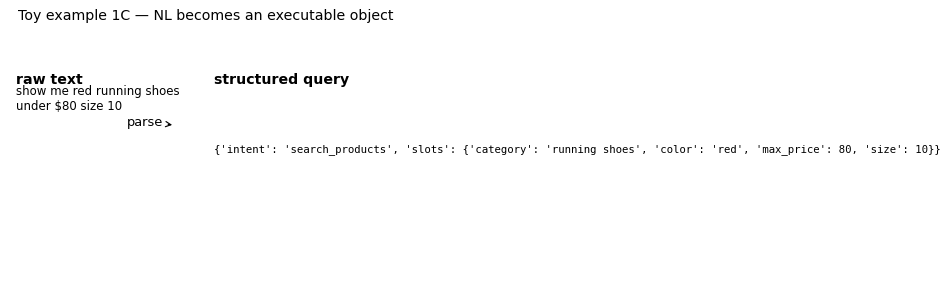

In [8]:
def parse_query(text):
    scores, _ = keyword_intent_scores(text)
    intent = max(scores, key=scores.get)
    lower = text.lower()
    slots = {}

    if intent == "search_flights":
        dest = re.search(r"to\s+([a-z]+)", lower)
        if dest:
            slots["destination"] = dest.group(1).title()
            log("slot extraction", f"destination <- {slots['destination']}")
        if "next friday" in lower:
            slots["date"] = "next Friday"
            log("slot extraction", "date <- next Friday")
        if "cheap" in lower:
            slots["price"] = "low"
            log("slot extraction", "price <- low")

    if intent == "search_products":
        if "running shoes" in lower:
            slots["category"] = "running shoes"
            log("slot extraction", "category <- running shoes")
        for color in ["red", "blue", "black", "white", "crimson", "turquoise"]:
            if color in lower:
                slots["color"] = color
                log("slot extraction", f"color <- {color}")
                break
        price = re.search(r"under\s*\$?(\d+)", lower)
        if price:
            slots["max_price"] = int(price.group(1))
            log("slot extraction", f"max_price <- {slots['max_price']}")
        size = re.search(r"size\s*(\d+)", lower)
        if size:
            slots["size"] = int(size.group(1))
            log("slot extraction", f"size <- {slots['size']}")

    return {"intent": intent, "slots": slots, "intent_scores": scores}

flight_parse = parse_query("cheap flights to tokyo next friday")
product_parse = parse_query("show me red running shoes under $80 size 10")
log("parsed flight dict", flight_parse)
log("parsed product dict", product_parse)

expected_flight = {"intent": "search_flights", "slots": {"destination": "Tokyo", "date": "next Friday", "price": "low"}}
expected_product = {"intent": "search_products", "slots": {"category": "running shoes", "color": "red", "max_price": 80, "size": 10}}
assert {"intent": flight_parse["intent"], "slots": flight_parse["slots"]} == expected_flight
assert {"intent": product_parse["intent"], "slots": product_parse["slots"]} == expected_product

fig, ax = plt.subplots()
ax.axis("off")
ax.text(0.02, 0.78, "raw text", fontsize=12, weight="bold")
ax.text(0.02, 0.68, "show me red running shoes\nunder $80 size 10", fontsize=10)
ax.annotate("parse", xy=(0.42, 0.62), xytext=(0.30, 0.62), arrowprops=dict(arrowstyle="->"), fontsize=11)
ax.text(0.52, 0.78, "structured query", fontsize=12, weight="bold")
ax.text(0.52, 0.52, str(expected_product), fontsize=9, family="monospace")
plt.title("Toy example 1C — NL becomes an executable object")
plt.show()

## Toy example 1D · Structured query means executable parameters

Once the parse is structured, downstream code does not need to understand English. It just reads fields like
`intent`, `color`, and `max_price`.

[structured query table] example          intent  slot_count                                                                      slots
 flight  search_flights           3            {'destination': 'Tokyo', 'date': 'next Friday', 'price': 'low'}
product search_products           4 {'category': 'running shoes', 'color': 'red', 'max_price': 80, 'size': 10}
[API could receive] {'category': 'running shoes', 'color': 'red', 'max_price': 80, 'size': 10}
[intermediate number: product slot_count] 4


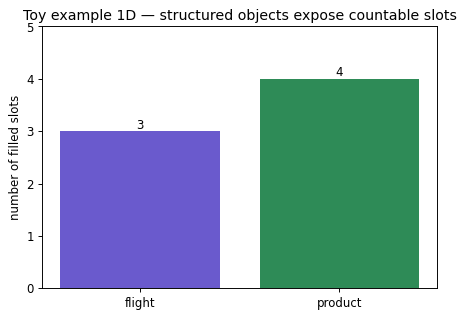

In [10]:
rows = []
for name, parsed in [("flight", flight_parse), ("product", product_parse)]:
    rows.append({"example": name, "intent": parsed["intent"], "slot_count": len(parsed["slots"]), "slots": parsed["slots"]})
summary = pd.DataFrame(rows)
log("structured query table", summary.to_string(index=False))

product_api_params = product_parse["slots"].copy()
log("API could receive", product_api_params)
log("intermediate number: product slot_count", len(product_api_params))
assert len(product_api_params) == 4

plt.bar(summary["example"], summary["slot_count"], color=["slateblue", "seagreen"])
for i, v in enumerate(summary["slot_count"]):
    plt.text(i, v + 0.05, str(v), ha="center")
plt.ylabel("number of filled slots")
plt.title("Toy example 1D — structured objects expose countable slots")
plt.ylim(0, 5)
plt.show()

---
# Part 2 · Retrieval-grounded interpretation

## Toy example 2A · Grounding against a catalog

**Grounding** means checking a parsed value against trusted data. A parser might output `crimson`, but the real
catalog might only allow `[red, blue, black, white]`.

We use nearest-match scoring:
- exact match = `1.0`
- substring match = `0.6`
- otherwise = `0.2`

The **accept threshold** is `0.5`: accept scores at or above it, reject scores below it.

**Good for:** catching hallucinated or unsupported slot values before execution.  
**Watch out for:** too-low thresholds accept bad values; too-high thresholds reject valid user language.

[input color] red
[candidate scores] {'red': 1.0, 'blue': 0.2, 'black': 0.2, 'white': 0.2}
[nearest + decision] red (match 1.00) -> ACCEPT
[input color] crimson
[candidate scores] {'red': 0.2, 'blue': 0.2, 'black': 0.2, 'white': 0.2}
[nearest + decision] red (match 0.20) -> REJECT
[input color] turquoise
[candidate scores] {'red': 0.2, 'blue': 0.2, 'black': 0.2, 'white': 0.2}
[nearest + decision] red (match 0.20) -> REJECT


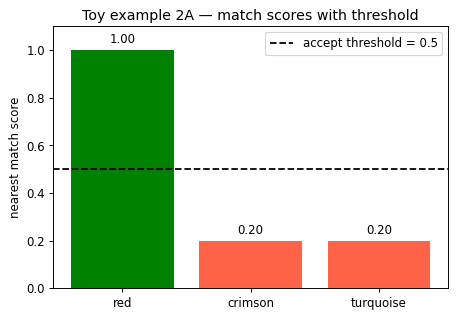

In [13]:
valid_colors = ["red", "blue", "black", "white"]
ACCEPT_THRESHOLD = 0.5

def toy_similarity(user_value, catalog_value):
    u = user_value.lower()
    c = catalog_value.lower()
    if u == c:
        return 1.0
    if u in c or c in u:
        return 0.6
    return 0.2

def nearest_catalog_value(user_value, catalog):
    scores = [toy_similarity(user_value, candidate) for candidate in catalog]
    best_i = int(np.argmax(scores))
    return catalog[best_i], scores[best_i], dict(zip(catalog, scores))

color_inputs = ["red", "crimson", "turquoise"]
score_rows = []
for color in color_inputs:
    nearest, score, score_dict = nearest_catalog_value(color, valid_colors)
    accepted = score >= ACCEPT_THRESHOLD
    score_rows.append({"input": color, "nearest": nearest, "score": score, "accepted": accepted})
    log("input color", color)
    log("candidate scores", score_dict)
    log("nearest + decision", f"{nearest} (match {score:.2f}) -> {'ACCEPT' if accepted else 'REJECT'}")

grounding_df = pd.DataFrame(score_rows)
assert grounding_df.loc[grounding_df.input == "red", "accepted"].iloc[0] is True or bool(grounding_df.loc[grounding_df.input == "red", "accepted"].iloc[0])
assert not bool(grounding_df.loc[grounding_df.input == "crimson", "accepted"].iloc[0])
assert not bool(grounding_df.loc[grounding_df.input == "turquoise", "accepted"].iloc[0])

plt.bar(grounding_df["input"], grounding_df["score"], color=["green" if x else "tomato" for x in grounding_df["accepted"]])
plt.axhline(ACCEPT_THRESHOLD, color="black", linestyle="--", label="accept threshold = 0.5")
for i, row in grounding_df.iterrows():
    plt.text(i, row["score"] + 0.03, f"{row['score']:.2f}", ha="center")
plt.ylabel("nearest match score")
plt.ylim(0, 1.1)
plt.title("Toy example 2A — match scores with threshold")
plt.legend()
plt.show()

## Toy example 2B · Accept/reject decisions are part of the parse

A grounded slot should remember both the raw user value and the catalog value it matched. This makes the
system inspectable: we can explain why `red` was accepted and `crimson` was rejected.

[ground_color_slot] {'raw': 'red', 'nearest': 'red', 'score': 1.0, 'accepted': True}
[ground_color_slot] {'raw': 'crimson', 'nearest': 'red', 'score': 0.2, 'accepted': False}
[ground_color_slot] {'raw': 'turquoise', 'nearest': 'red', 'score': 0.2, 'accepted': False}
[accepted count] 1
[rejected count] 2


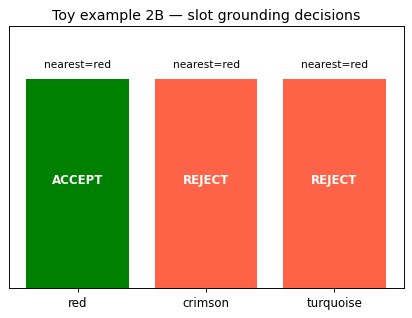

In [15]:
def ground_color_slot(raw_color):
    nearest, score, _ = nearest_catalog_value(raw_color, valid_colors)
    accepted = score >= ACCEPT_THRESHOLD
    result = {"raw": raw_color, "nearest": nearest, "score": score, "accepted": accepted}
    log("ground_color_slot", result)
    return result

grounded_colors = [ground_color_slot(c) for c in color_inputs]
accepted_count = sum(item["accepted"] for item in grounded_colors)
rejected_count = len(grounded_colors) - accepted_count
log("accepted count", accepted_count)
log("rejected count", rejected_count)
assert accepted_count == 1
assert rejected_count == 2

labels = [item["raw"] for item in grounded_colors]
colors = ["green" if item["accepted"] else "tomato" for item in grounded_colors]
plt.bar(labels, [1, 1, 1], color=colors)
for i, item in enumerate(grounded_colors):
    plt.text(i, 0.50, "ACCEPT" if item["accepted"] else "REJECT", ha="center", color="white", weight="bold")
    plt.text(i, 1.05, f"nearest={item['nearest']}", ha="center", fontsize=9)
plt.ylim(0, 1.25)
plt.yticks([])
plt.title("Toy example 2B — slot grounding decisions")
plt.show()

## Toy example 2C · Grounding a whole product parse

The parser may fill many slots. Grounding can accept one slot and reject another without throwing away the
entire query immediately.

[slot extraction] category <- running shoes
[slot extraction] color <- crimson
[slot extraction] max_price <- 80
[slot extraction] size <- 10
[raw parsed dict] {'intent': 'search_products', 'slots': {'category': 'running shoes', 'color': 'crimson', 'max_price': 80, 'size': 10}, 'intent_scores': {'search_flights': 0.14285714285714285, 'search_products': 0.8571428571428571}}
[ground_color_slot] {'raw': 'crimson', 'nearest': 'red', 'score': 0.2, 'accepted': False}
[grounded product] {'category': 'running shoes', 'color': None, 'max_price': 80, 'size': 10, 'color_error': 'not in catalog'}
[slot accepted flags] {'category': True, 'color': False, 'max_price': True, 'size': True}


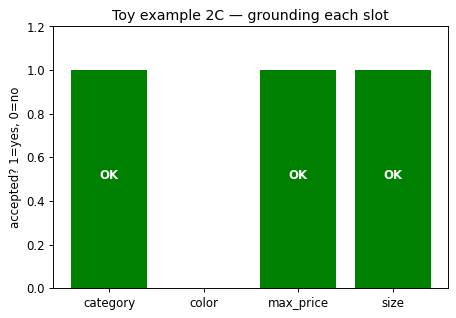

In [17]:
crimson_parse = parse_query("show me crimson running shoes under $80 size 10")
log("raw parsed dict", crimson_parse)

grounded_product = crimson_parse["slots"].copy()
color_grounding = ground_color_slot(grounded_product["color"])
if color_grounding["accepted"]:
    grounded_product["color"] = color_grounding["nearest"]
else:
    grounded_product["color"] = None
    grounded_product["color_error"] = "not in catalog"

slot_status = {
    "category": grounded_product.get("category") is not None,
    "color": grounded_product.get("color") is not None,
    "max_price": grounded_product.get("max_price") is not None,
    "size": grounded_product.get("size") is not None,
}
log("grounded product", grounded_product)
log("slot accepted flags", slot_status)
assert slot_status["category"] and not slot_status["color"] and slot_status["max_price"] and slot_status["size"]

plt.bar(slot_status.keys(), [int(v) for v in slot_status.values()], color=["green" if v else "tomato" for v in slot_status.values()])
for i, (slot, ok) in enumerate(slot_status.items()):
    plt.text(i, 0.5, "OK" if ok else "REJECT", ha="center", color="white", weight="bold")
plt.ylim(0, 1.2)
plt.ylabel("accepted? 1=yes, 0=no")
plt.title("Toy example 2C — grounding each slot")
plt.show()

---
# Part 3 · Confidence score

## Toy example 3A · Confidence from four behavioral signals

**Confidence** is a score for how trustworthy the whole parse is. Do **not** rely only on an LLM saying
"I am confident"; self-reported confidence is often poorly calibrated. Prefer behavioral signals you can
measure.

Signals in this toy notebook:
- **slot_fill_rate:** fraction of required slots filled.
- **ground_match:** how well slot values matched trusted catalogs.
- **intent_prob:** parser's probability for the chosen intent.
- **retrieval_sim:** similarity between the query and retrieved evidence.

Weighted-average formula:

$\text{confidence} = 0.25\cdot\text{slot\_fill\_rate} + 0.30\cdot\text{ground\_match} + 0.25\cdot\text{intent\_prob} + 0.20\cdot\text{retrieval\_sim}$

**Good for:** routing based on multiple measurable signals.  
**Watch out for:** tune weights on real traffic; toy weights are for learning, not production.

[case] clear red shoes size 10
[signals] {'slot_fill_rate': 1.0, 'ground_match': 1.0, 'intent_prob': 0.95, 'retrieval_sim': 0.9}
[weighted contributions] {'slot_fill_rate': 0.25, 'ground_match': 0.3, 'intent_prob': 0.238, 'retrieval_sim': 0.18}
[final confidence] 0.9675
[case] vague something nice
[signals] {'slot_fill_rate': 0.2, 'ground_match': 0.3, 'intent_prob': 0.4, 'retrieval_sim': 0.35}
[weighted contributions] {'slot_fill_rate': 0.05, 'ground_match': 0.09, 'intent_prob': 0.1, 'retrieval_sim': 0.07}
[final confidence] 0.31
[case] typo flights to tokoyo
[signals] {'slot_fill_rate': 0.8, 'ground_match': 0.7, 'intent_prob': 0.85, 'retrieval_sim': 0.6}
[weighted contributions] {'slot_fill_rate': 0.2, 'ground_match': 0.21, 'intent_prob': 0.212, 'retrieval_sim': 0.12}
[final confidence] 0.7425


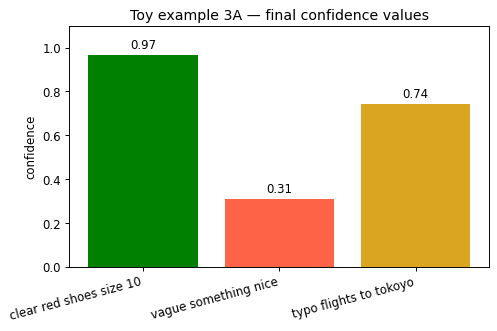

In [20]:
signal_names = ["slot_fill_rate", "ground_match", "intent_prob", "retrieval_sim"]
weights = np.array([0.25, 0.30, 0.25, 0.20])
confidence_cases = {
    "clear red shoes size 10": np.array([1.0, 1.0, 0.95, 0.90]),
    "vague something nice": np.array([0.2, 0.3, 0.40, 0.35]),
    "typo flights to tokoyo": np.array([0.8, 0.7, 0.85, 0.60]),
}
expected_confidences = {
    "clear red shoes size 10": 0.97,
    "vague something nice": 0.31,
    "typo flights to tokoyo": 0.74,
}

def confidence(signals):
    return float(np.sum(weights * signals))

conf_rows = []
for name, signals in confidence_cases.items():
    contributions = weights * signals
    conf = confidence(signals)
    conf_rows.append({"case": name, "confidence": conf})
    log("case", name)
    log("signals", dict(zip(signal_names, np.round(signals, 3))))
    log("weighted contributions", dict(zip(signal_names, np.round(contributions, 3))))
    log("final confidence", round(conf, 4))
    assert round(conf, 2) == expected_confidences[name]

conf_df = pd.DataFrame(conf_rows)
plt.bar(conf_df["case"], conf_df["confidence"], color=["green", "tomato", "goldenrod"])
for i, row in conf_df.iterrows():
    plt.text(i, row["confidence"] + 0.03, f"{row['confidence']:.2f}", ha="center")
plt.ylim(0, 1.1)
plt.ylabel("confidence")
plt.xticks(rotation=15, ha="right")
plt.title("Toy example 3A — final confidence values")
plt.tight_layout()
plt.show()

## Toy example 3B · Which signal contributed what?

The same confidence score can be explained by showing each weighted contribution. This is useful when a user
or developer asks, "Why did the router hesitate?"

[case contribution sum] clear red shoes size 10: 0.9675
[  slot_fill_rate] 0.25
[  ground_match] 0.3
[  intent_prob] 0.2375
[  retrieval_sim] 0.18
[case contribution sum] vague something nice: 0.3100
[  slot_fill_rate] 0.05
[  ground_match] 0.09
[  intent_prob] 0.1
[  retrieval_sim] 0.07
[case contribution sum] typo flights to tokoyo: 0.7425
[  slot_fill_rate] 0.2
[  ground_match] 0.21
[  intent_prob] 0.2125
[  retrieval_sim] 0.12


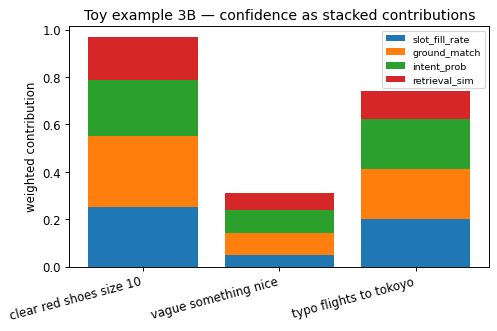

In [22]:
contrib_matrix = np.vstack([weights * signals for signals in confidence_cases.values()])
case_names = list(confidence_cases.keys())
for case_name, contribs in zip(case_names, contrib_matrix):
    log("case contribution sum", f"{case_name}: {contribs.sum():.4f}")
    for sig, val in zip(signal_names, contribs):
        log(f"  {sig}", round(float(val), 4))

bottom = np.zeros(len(case_names))
for j, sig in enumerate(signal_names):
    plt.bar(case_names, contrib_matrix[:, j], bottom=bottom, label=sig)
    bottom += contrib_matrix[:, j]
plt.ylabel("weighted contribution")
plt.xticks(rotation=15, ha="right")
plt.title("Toy example 3B — confidence as stacked contributions")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Toy example 3C · Why not trust self-reported confidence?

A model can sound certain while being wrong. In this toy comparison, behavioral confidence is lower when slots
are missing or not grounded, even if a fictional self-report stays high.

[case] clear red shoes size 10
[fictional self-reported confidence] 0.99
[behavioral confidence from signals] 0.97
[gap] 0.02
[case] vague something nice
[fictional self-reported confidence] 0.9
[behavioral confidence from signals] 0.31
[gap] 0.59
[case] typo flights to tokoyo
[fictional self-reported confidence] 0.92
[behavioral confidence from signals] 0.74
[gap] 0.18


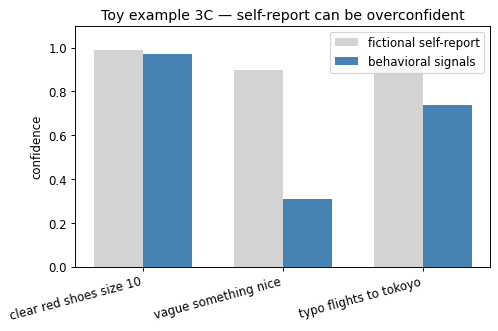

In [24]:
self_reported = np.array([0.99, 0.90, 0.92])
behavioral = np.array([expected_confidences[name] for name in confidence_cases])
for name, self_c, beh_c in zip(confidence_cases, self_reported, behavioral):
    log("case", name)
    log("fictional self-reported confidence", self_c)
    log("behavioral confidence from signals", beh_c)
    log("gap", round(float(self_c - beh_c), 2))
assert behavioral[1] < 0.45

x = np.arange(len(case_names))
width = 0.35
plt.bar(x - width/2, self_reported, width, label="fictional self-report", color="lightgray")
plt.bar(x + width/2, behavioral, width, label="behavioral signals", color="steelblue")
plt.xticks(x, case_names, rotation=15, ha="right")
plt.ylim(0, 1.1)
plt.ylabel("confidence")
plt.title("Toy example 3C — self-report can be overconfident")
plt.legend()
plt.tight_layout()
plt.show()

---
# Part 4 · Low-confidence fallback router

## Toy example 4A · Three routes from two thresholds

A **fallback** is the safe behavior when confidence is too low, such as keyword search or a clarifying question.

Thresholds:
- `HIGH = 0.75`: confidence at or above this can **EXECUTE** the structured query.
- `LOW = 0.45`: confidence below this should **FALLBACK**.
- between them means **CONFIRM** or clarify before execution.

**Good for:** preventing a wrong parse from silently running.  
**Watch out for:** thresholds must be tuned and monitored; bad thresholds can frustrate users or create risk.

[routing decision] clear red shoes size 10: confidence=0.97 -> EXECUTE
[routing decision] vague something nice: confidence=0.31 -> FALLBACK
[routing decision] typo flights to tokoyo: confidence=0.74 -> CONFIRM


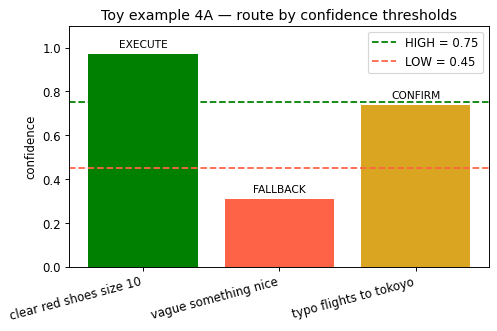

In [27]:
HIGH = 0.75
LOW = 0.45

def route(conf):
    if conf >= HIGH:
        return "EXECUTE"
    if conf >= LOW:
        return "CONFIRM"
    return "FALLBACK"

routes = {}
for name in confidence_cases:
    rounded_conf = expected_confidences[name]
    routes[name] = route(rounded_conf)
    log("routing decision", f"{name}: confidence={rounded_conf:.2f} -> {routes[name]}")

assert routes["clear red shoes size 10"] == "EXECUTE"
assert routes["typo flights to tokoyo"] == "CONFIRM"
assert routes["vague something nice"] == "FALLBACK"

route_colors = {"EXECUTE": "green", "CONFIRM": "goldenrod", "FALLBACK": "tomato"}
plt.bar(case_names, behavioral, color=[route_colors[routes[name]] for name in case_names])
plt.axhline(HIGH, color="green", linestyle="--", label="HIGH = 0.75")
plt.axhline(LOW, color="tomato", linestyle="--", label="LOW = 0.45")
for i, name in enumerate(case_names):
    plt.text(i, behavioral[i] + 0.03, routes[name], ha="center", fontsize=9)
plt.ylim(0, 1.1)
plt.ylabel("confidence")
plt.xticks(rotation=15, ha="right")
plt.title("Toy example 4A — route by confidence thresholds")
plt.legend()
plt.tight_layout()
plt.show()

## Toy example 4B · What each route says to the user

The route changes the user experience. High confidence runs the query. Medium confidence asks the user to
confirm. Low confidence does not pretend it knows.

[case] clear red shoes size 10
[route] EXECUTE
[message] Execute structured query: clear red shoes size 10
[case] vague something nice
[route] FALLBACK
[message] Fallback: use keyword search or ask a clarifying question.
[case] typo flights to tokoyo
[route] CONFIRM
[message] Confirm first: Did you mean flights to tokoyo?
[route counts] {'EXECUTE': 1, 'CONFIRM': 1, 'FALLBACK': 1}


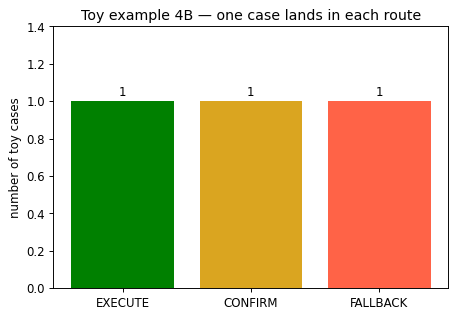

In [29]:
def action_message(route_name, parsed_hint):
    if route_name == "EXECUTE":
        return f"Execute structured query: {parsed_hint}"
    if route_name == "CONFIRM":
        return f"Confirm first: Did you mean {parsed_hint}?"
    return "Fallback: use keyword search or ask a clarifying question."

messages = {}
for name in case_names:
    parsed_hint = name.replace("typo ", "").replace("vague ", "")
    messages[name] = action_message(routes[name], parsed_hint)
    log("case", name)
    log("route", routes[name])
    log("message", messages[name])

route_counts = pd.Series(list(routes.values())).value_counts().reindex(["EXECUTE", "CONFIRM", "FALLBACK"], fill_value=0)
log("route counts", route_counts.to_dict())
assert route_counts.to_dict() == {"EXECUTE": 1, "CONFIRM": 1, "FALLBACK": 1}

plt.bar(route_counts.index, route_counts.values, color=[route_colors[r] for r in route_counts.index])
for i, v in enumerate(route_counts.values):
    plt.text(i, v + 0.03, str(v), ha="center")
plt.ylim(0, 1.4)
plt.ylabel("number of toy cases")
plt.title("Toy example 4B — one case lands in each route")
plt.show()

## Toy example 4C · Threshold tuning intuition

A router is not magic. Teams tune `LOW` and `HIGH` on real traffic, labels, user corrections, and safety needs.
This toy sweep shows that moving thresholds changes how many queries execute.

[scenario] {'name': 'strict', 'low': 0.55, 'high': 0.85}
[routes] ['EXECUTE', 'FALLBACK', 'CONFIRM']
[counts] {'EXECUTE': 1, 'CONFIRM': 1, 'FALLBACK': 1}
[scenario] {'name': 'lesson default', 'low': 0.45, 'high': 0.75}
[routes] ['EXECUTE', 'FALLBACK', 'CONFIRM']
[counts] {'EXECUTE': 1, 'CONFIRM': 1, 'FALLBACK': 1}
[scenario] {'name': 'loose', 'low': 0.3, 'high': 0.65}
[routes] ['EXECUTE', 'CONFIRM', 'EXECUTE']
[counts] {'EXECUTE': 2, 'CONFIRM': 1, 'FALLBACK': 0}


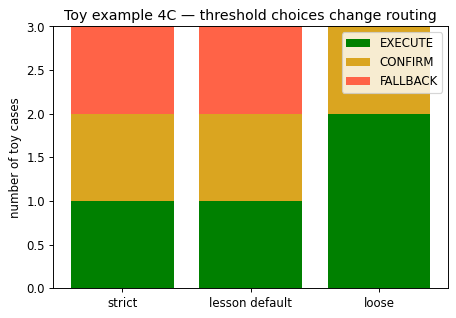

In [31]:
threshold_scenarios = [
    {"name": "strict", "low": 0.55, "high": 0.85},
    {"name": "lesson default", "low": LOW, "high": HIGH},
    {"name": "loose", "low": 0.30, "high": 0.65},
]
scenario_rows = []
for scenario in threshold_scenarios:
    scenario_routes = []
    for conf in behavioral:
        if conf >= scenario["high"]:
            scenario_routes.append("EXECUTE")
        elif conf >= scenario["low"]:
            scenario_routes.append("CONFIRM")
        else:
            scenario_routes.append("FALLBACK")
    counts = pd.Series(scenario_routes).value_counts().reindex(["EXECUTE", "CONFIRM", "FALLBACK"], fill_value=0)
    scenario_rows.append(counts.values)
    log("scenario", scenario)
    log("routes", scenario_routes)
    log("counts", counts.to_dict())

scenario_rows = np.array(scenario_rows)
bottom = np.zeros(len(threshold_scenarios))
for idx, route_name in enumerate(["EXECUTE", "CONFIRM", "FALLBACK"]):
    plt.bar([s["name"] for s in threshold_scenarios], scenario_rows[:, idx], bottom=bottom, label=route_name, color=route_colors[route_name])
    bottom += scenario_rows[:, idx]
plt.ylabel("number of toy cases")
plt.title("Toy example 4C — threshold choices change routing")
plt.legend()
plt.show()

---
# Part 5 · Whole module as one chain

## Toy example 5A · Full pipeline pseudocode

Plain-English pseudocode:

1. **parse** natural language into `{intent, slots}`.
2. **ground** each important slot against trusted data.
3. **score** confidence from behavioral signals.
4. **route**: execute, confirm, or fallback.
5. If trustworthy, feed the structured query into M18-style RAG retrieval so retrieval is based on grounded fields.

**Good for:** connecting query understanding to a RAG retriever.  
**Watch out for:** parsing and retrieval are separate failure points; log both.

[pipeline input] show me red running shoes under $80 size 10
[slot extraction] category <- running shoes
[slot extraction] color <- red
[slot extraction] max_price <- 80
[slot extraction] size <- 10
[1 parse] {'intent': 'search_products', 'slots': {'category': 'running shoes', 'color': 'red', 'max_price': 80, 'size': 10}}
[ground_color_slot] {'raw': 'red', 'nearest': 'red', 'score': 1.0, 'accepted': True}
[2 color grounding] {'raw': 'red', 'nearest': 'red', 'score': 1.0, 'accepted': True}
[3 confidence] 0.9675
[4 route] EXECUTE
[pipeline input] cheap flights to tokoyo next friday
[slot extraction] destination <- Tokoyo
[slot extraction] date <- next Friday
[slot extraction] price <- low
[1 parse] {'intent': 'search_flights', 'slots': {'destination': 'Tokoyo', 'date': 'next Friday', 'price': 'low'}}
[2 color grounding] no color slot to ground
[3 confidence] 0.7425
[4 route] CONFIRM
[pipeline input] something nice
[1 parse] {'intent': 'search_flights', 'slots': {}}
[2 color grounding] no

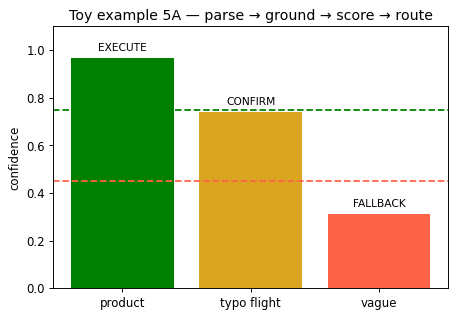

In [34]:
def run_toy_pipeline(query, signals):
    log("pipeline input", query)
    parsed = parse_query(query)
    log("1 parse", {"intent": parsed["intent"], "slots": parsed["slots"]})

    grounded_slots = parsed["slots"].copy()
    if "color" in grounded_slots:
        g = ground_color_slot(grounded_slots["color"])
        grounded_slots["color"] = g["nearest"] if g["accepted"] else None
        log("2 color grounding", g)
    else:
        log("2 color grounding", "no color slot to ground")

    conf = confidence(signals)
    r = route(round(conf, 2))
    log("3 confidence", round(conf, 4))
    log("4 route", r)
    return {"query": query, "parsed": parsed, "grounded_slots": grounded_slots, "confidence": conf, "route": r}

pipeline_examples = [
    ("show me red running shoes under $80 size 10", confidence_cases["clear red shoes size 10"]),
    ("cheap flights to tokoyo next friday", confidence_cases["typo flights to tokoyo"]),
    ("something nice", confidence_cases["vague something nice"]),
]
pipeline_results = [run_toy_pipeline(q, sig) for q, sig in pipeline_examples]
assert [r["route"] for r in pipeline_results] == ["EXECUTE", "CONFIRM", "FALLBACK"]

plt.bar(["product", "typo flight", "vague"], [r["confidence"] for r in pipeline_results], color=[route_colors[r["route"]] for r in pipeline_results])
plt.axhline(HIGH, color="green", linestyle="--")
plt.axhline(LOW, color="tomato", linestyle="--")
for i, r in enumerate(pipeline_results):
    plt.text(i, r["confidence"] + 0.03, r["route"], ha="center", fontsize=9)
plt.ylim(0, 1.1)
plt.ylabel("confidence")
plt.title("Toy example 5A — parse → ground → score → route")
plt.show()

## Toy example 5B · Executable structured query after trust checks

When route is `EXECUTE`, the downstream retriever can safely use the grounded slots as filters. Here we build a
tiny SQL-like string just to show the idea; no database is needed.

[trusted route] EXECUTE
[grounded slots] {'category': 'running shoes', 'color': 'red', 'max_price': 80, 'size': 10}
[executable filter] category = 'running shoes' AND color = 'red' AND price <= 80 AND size = 10


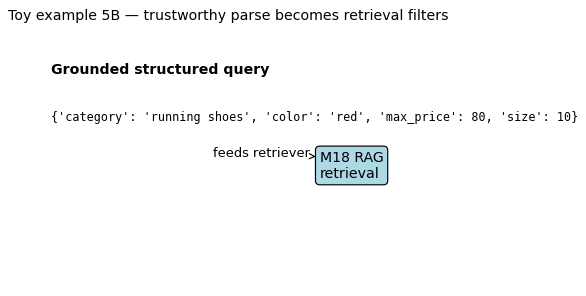

In [36]:
def build_product_filter(slots):
    parts = []
    if slots.get("category"):
        parts.append(f"category = '{slots['category']}'")
    if slots.get("color"):
        parts.append(f"color = '{slots['color']}'")
    if slots.get("max_price") is not None:
        parts.append(f"price <= {slots['max_price']}")
    if slots.get("size") is not None:
        parts.append(f"size = {slots['size']}")
    return " AND ".join(parts)

trusted = pipeline_results[0]
filter_string = build_product_filter(trusted["grounded_slots"])
log("trusted route", trusted["route"])
log("grounded slots", trusted["grounded_slots"])
log("executable filter", filter_string)
assert trusted["route"] == "EXECUTE"
assert "color = 'red'" in filter_string

fig, ax = plt.subplots()
ax.axis("off")
ax.text(0.05, 0.82, "Grounded structured query", fontsize=12, weight="bold")
ax.text(0.05, 0.64, str(trusted["grounded_slots"]), family="monospace", fontsize=10)
ax.annotate("feeds retriever", xy=(0.72, 0.50), xytext=(0.46, 0.50), arrowprops=dict(arrowstyle="->"), fontsize=11)
ax.text(0.73, 0.42, "M18 RAG\nretrieval", fontsize=12, bbox=dict(boxstyle="round", facecolor="lightblue"))
plt.title("Toy example 5B — trustworthy parse becomes retrieval filters")
plt.show()

## Toy example 5C · Safe fallback for low confidence

For a low-confidence parse, the system should not execute a detailed structured query. It can drop to keyword
search or ask a clarifying question.

[low-confidence query] something nice
[route] FALLBACK
[fallback keyword terms] ['something', 'nice']
[clarifying question] Can you tell me the product, destination, or key filter you want?


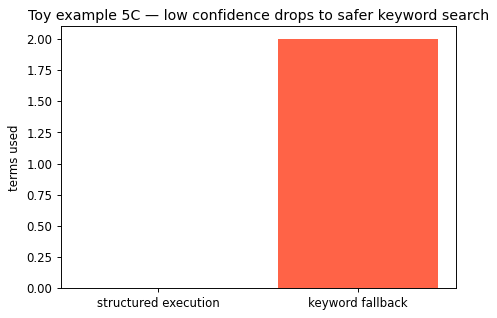

In [38]:
def fallback_plan(query):
    keywords = re.findall(r"[a-z]+", query.lower())
    question = "Can you tell me the product, destination, or key filter you want?"
    return {"keyword_search_terms": keywords, "clarifying_question": question}

low_result = pipeline_results[2]
plan = fallback_plan(low_result["query"])
log("low-confidence query", low_result["query"])
log("route", low_result["route"])
log("fallback keyword terms", plan["keyword_search_terms"])
log("clarifying question", plan["clarifying_question"])
assert low_result["route"] == "FALLBACK"
assert plan["keyword_search_terms"] == ["something", "nice"]

plt.bar(["structured execution", "keyword fallback"], [0, len(plan["keyword_search_terms"])], color=["lightgray", "tomato"])
plt.ylabel("terms used")
plt.title("Toy example 5C — low confidence drops to safer keyword search")
plt.show()

## Toy example 5D · Final sanity checks

Before shipping a query-understanding pipeline, check that the important invariants are pinned by tests:
expected parses, grounding decisions, confidence values, and routing decisions.

[flight parse exact] True
[product parse exact] True
[red accepted] True
[crimson rejected] True
[turquoise rejected] True
[clear confidence 0.97] True
[vague confidence 0.31] True
[typo confidence 0.74] True
[routes pinned] True
[passed checks] 9 / 9


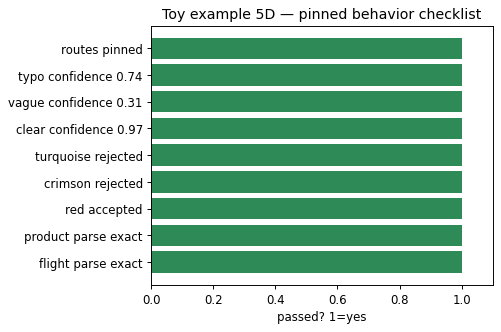

In [40]:
checks = {
    "flight parse exact": {"intent": flight_parse["intent"], "slots": flight_parse["slots"]} == expected_flight,
    "product parse exact": {"intent": product_parse["intent"], "slots": product_parse["slots"]} == expected_product,
    "red accepted": bool(grounding_df.loc[grounding_df.input == "red", "accepted"].iloc[0]),
    "crimson rejected": not bool(grounding_df.loc[grounding_df.input == "crimson", "accepted"].iloc[0]),
    "turquoise rejected": not bool(grounding_df.loc[grounding_df.input == "turquoise", "accepted"].iloc[0]),
    "clear confidence 0.97": expected_confidences["clear red shoes size 10"] == 0.97,
    "vague confidence 0.31": expected_confidences["vague something nice"] == 0.31,
    "typo confidence 0.74": expected_confidences["typo flights to tokoyo"] == 0.74,
    "routes pinned": [routes[n] for n in case_names] == ["EXECUTE", "FALLBACK", "CONFIRM"],
}
for label, ok in checks.items():
    log(label, ok)
assert all(checks.values())
log("passed checks", f"{sum(checks.values())} / {len(checks)}")

plt.barh(list(checks.keys()), [int(v) for v in checks.values()], color="seagreen")
plt.xlim(0, 1.1)
plt.xlabel("passed? 1=yes")
plt.title("Toy example 5D — pinned behavior checklist")
plt.tight_layout()
plt.show()

## Toy example 5E · One-line chain table

The final view is a compact audit table: each row keeps the query, confidence, and route together so a human
can inspect why the system did or did not execute.

[audit table]                                       query          intent  confidence    route
show me red running shoes under $80 size 10 search_products        0.97  EXECUTE
        cheap flights to tokoyo next friday  search_flights        0.74  CONFIRM
                             something nice  search_flights        0.31 FALLBACK
[execute rows] 1
[non-execute rows] 2


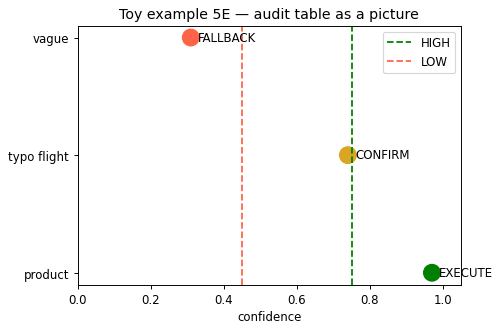

In [42]:
audit_rows = []
for result in pipeline_results:
    audit_rows.append({
        "query": result["query"],
        "intent": result["parsed"]["intent"],
        "confidence": round(result["confidence"], 2),
        "route": result["route"],
    })
audit_df = pd.DataFrame(audit_rows)
log("audit table", audit_df.to_string(index=False))
log("execute rows", int((audit_df["route"] == "EXECUTE").sum()))
log("non-execute rows", int((audit_df["route"] != "EXECUTE").sum()))
assert audit_df["route"].tolist() == ["EXECUTE", "CONFIRM", "FALLBACK"]

plt.scatter(audit_df["confidence"], np.arange(len(audit_df)), s=200,
            c=[route_colors[r] for r in audit_df["route"]])
for i, row in audit_df.iterrows():
    plt.text(row["confidence"] + 0.02, i, row["route"], va="center")
plt.axvline(HIGH, color="green", linestyle="--", label="HIGH")
plt.axvline(LOW, color="tomato", linestyle="--", label="LOW")
plt.yticks(np.arange(len(audit_df)), ["product", "typo flight", "vague"])
plt.xlim(0, 1.05)
plt.xlabel("confidence")
plt.title("Toy example 5E — audit table as a picture")
plt.legend()
plt.tight_layout()
plt.show()

## Recap — M19 as one chain

**Whole module chain:** natural-language query → `{intent, slots}` → grounded slots → weighted confidence → safe route → RAG retrieval when trusted.

Two big takeaways:
1. **Parse + ground** turns natural language into an executable query and grounds out hallucinations.
2. **Confidence + fallback** prevents executing a wrong-but-confident parse.

Practical reminders:
- Define every important slot and test it with toy cases before scaling up.
- Prefer behavioral confidence signals over self-reported confidence.
- Tune thresholds on real traffic, not vibes.
- Log parse, grounding, confidence, and route so failures are explainable.